# Implementation of LuKARS 3.0 - Baget



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
import numpy as np
import os

## 1 - Model functions

#### Upper compartments 

In [2]:
# Upper-compartment model function is defined in lukars_model.py
from lukars_model import Q_up


#### karstmod functions (later used in the bottom compartment)

In [3]:
# Auxiliary lower-compartment functions are defined in lukars_model.py
from lukars_model import ki_seuil, Eth, MCth


#### Bottom compartments

In [4]:
# Bottom-compartment model function is defined in lukars_model.py
from lukars_model import Q_bot


#### Entire model

In [5]:
# Complete LuKARS model runner is defined in lukars_model.py
from lukars_model import run_model


## 2 - Input time series and parameters

#### Load precipitation data

In [6]:
## Load precipitation data

# Read the file 
ts = pd.read_csv('input.txt', sep='\t', index_col=0, decimal='.')

# Convert the index to datetime with the specified format
ts.index = pd.to_datetime(ts.index, format="%d/%m/%Y %H:%M")
# Extract the DateTime index as array  
date_index = ts.index.to_numpy()

#nparray the values from the 'P' column
pr = ts['P'].values
sns = pr 

In [7]:
ts.iloc[9000:10000]

,string,P,QobsS
Date,,,
2021-10-10 00:00:00,9000,0.0,0.070992
2021-10-10 01:00:00,9001,0.0,0.071781
2021-10-10 02:00:00,9002,0.0,0.068983
2021-10-10 03:00:00,9003,0.0,0.068090
2021-10-10 04:00:00,9004,0.0,0.068090
...,...,...,...
2021-11-20 11:00:00,9995,0.0,0.190479
2021-11-20 12:00:00,9996,0.0,0.192947
2021-11-20 13:00:00,9997,0.0,0.192122


In [8]:
## NB: To change the number of hydrotopes or to deactivate a flux, only this section needs to be changes !!!!!!!!

# define the parameters
dt = 1 # unit time step  
TotalArea = 15* 1e6 # area in m2

# create parameter vectors for each single hydrotope (to be changed based on the number of hydrotopes (= nbCompartment))
nbCompartment = 2 # number of hydrotopes
ra = np.array([TotalArea * 0.7, TotalArea * 0.3]) # area 
kis = np.array([8.11E-05, 0]) # Coefficient for infiltration
Emin = np.array([1.02E+01, 4.80E+00]) # Lower storage threshold
Emax = np.array([1.42E+02, 2.35E+01]) # Upper storage threshold
alpha = np.array([1.98, 1.47]) # Exponent for fast flow
khy = np.array([2.73E+03, 4.75E+02]) # Coefficient for fast flow
lhy = np.array([3.17E+03,1.58E+03]) # Mean distance

# parameters for bottom compartment 
kMC = 2.06E-02 # Coefficient transfer matrix conduit
aMC = 2.90E+00  # Exponent transfer matrix conduit
C_loss = 2.0 # Threshold activation drain from conduit
M_loss = 100000000 # Threshold activation drain from matrix
kMS = 0 # Coefficient transfer matrix spring
aMS = 0 # Exponent transfer matrix spring
kCS = 7.74E-03 # Coefficient transfer conduit spring
aCS = 3.85E+00 # Exponent transfer conduit spring

## 3 - Model run

In [9]:
run_up, run_bot = run_model(dt, sns, 1, 1, 1, ra, kis, Emin, Emax, alpha, khy, lhy, TotalArea, 1, 0.5, kMC, aMC, C_loss, M_loss, kMS, aMS, kCS, aCS)

In [10]:
run_bot = np.array(run_bot) # extract results (from tuple of arrays to array of arrays)

In [11]:
# extract flow components and combine them with datetime using list
# list containing array datetime64[ns] (Date) and array float (values)
E = [date_index,run_up[0,:,:]]
Qis = [date_index,run_up[1,:,:]]
Qhy = [date_index,run_up[2,:,:]]
QEM = [date_index,run_bot[0,:]]
QEC = [date_index,run_bot[1,:]]
Q_C_loss = [date_index,run_bot[2,:]]
Q_M_loss = [date_index,run_bot[3,:]]
Q_M_S = [date_index,run_bot[4,:]]
Q_C_S = [date_index,run_bot[5,:]]
Q_M_C = [date_index,run_bot[6,:]]
Q_sim = [date_index,run_bot[7,:]]
C = [date_index,run_bot[8,:]]
M = [date_index,run_bot[9,:]]

## 4 - Plots

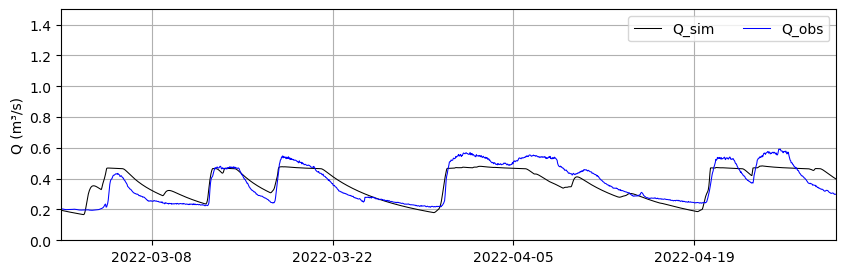

In [12]:
import matplotlib.pyplot as plt
from datetime import datetime

# Define start and end dates 
start_datetime = datetime(2022, 3, 1)
end_datetime = datetime(2022, 4, 30)

plt.figure(figsize=(10, 3))
plt.grid(True)

# Plot simulated and observed discharge
plt.plot(Q_sim[0], Q_sim[1], 'k-', linewidth=0.75, label='Q_sim')
plt.plot(Q_sim[0], ts['QobsS'], 'b-', linewidth=0.75, label='Q_obs')

plt.ylabel('Q (m³/s)')
plt.ylim(0, 1.5)
plt.xlim(start_datetime, end_datetime)
plt.legend(ncol=nbCompartment + 1)

# Format x-axis every 2 weeks
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))  # every 2 weeks

# Save the figure as a PNG file
plt.savefig("Qsim_plot.png", dpi=300, bbox_inches='tight')

# Optional: show the plot
plt.show()


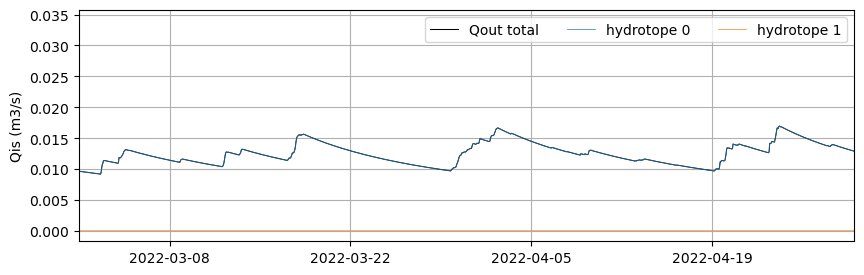

In [13]:
# plot Qis time series for each bucket
plt.figure(figsize=(10,3)) ; plt.grid(True)
plt.plot(Qis[0], Qis[1].sum(axis=1), 'k-', linewidth=0.75, label='Qout total')
for i in range(nbCompartment) :
    plt.plot(Qis[0], Qis[1][:,i], label=f'hydrotope {i}', linewidth=0.5)
plt.ylabel('Qis (m3/s)') 
plt.xlim(start_datetime, end_datetime) 
plt.legend(ncol=nbCompartment+1)

# Format x-axis every 2 weeks
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))  # every 2 weeks

# Save the figure as a PNG file
plt.savefig("Qis_plot.png", dpi=300, bbox_inches='tight')

# Optional: show the plot
plt.show()


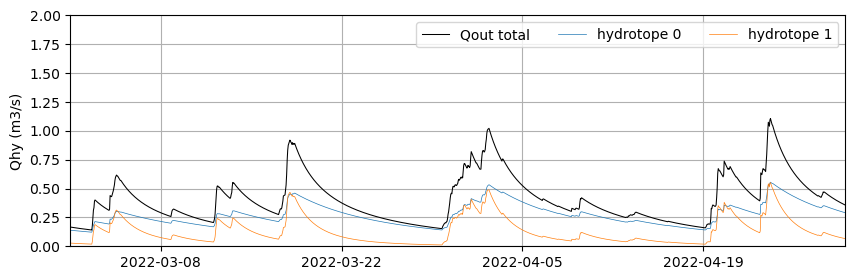

In [14]:
# plot Qhy time series for each bucket
plt.figure(figsize=(10,3)) ; plt.grid(True)
plt.plot(Qhy[0], Qhy[1].sum(axis=1), 'k-', linewidth=0.75, label='Qout total')
for i in range(nbCompartment) :
    plt.plot(Qhy[0], Qhy[1][:,i], label=f'hydrotope {i}', linewidth=0.5)
plt.ylabel('Qhy (m3/s)') 
plt.xlim(start_datetime, end_datetime) 
plt.ylim(0, 2)
plt.legend(ncol=nbCompartment+1)

# Format x-axis every 2 weeks
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))  # every 2 weeks

# Save the figure as a PNG file
plt.savefig("Qhyd_plot.png", dpi=300, bbox_inches='tight')

# Optional: show the plot
plt.show()


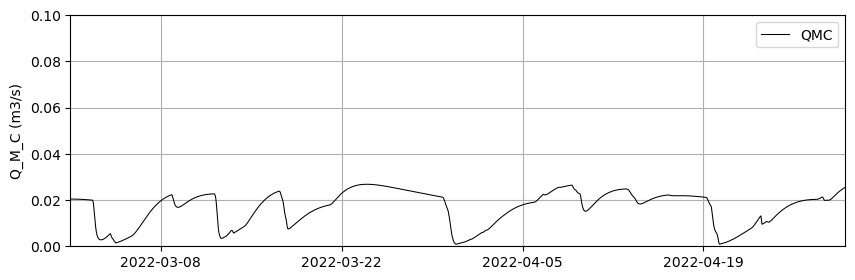

In [15]:
# plot Q_M_C
plt.figure(figsize=(10,3)) ; plt.grid(True)
plt.plot(Q_M_C[0], Q_M_C[1], 'k-', linewidth=0.75, label='QMC')
plt.ylabel('Q_M_C (m3/s)') 
plt.xlim(start_datetime, end_datetime) 
plt.ylim(0, 0.1)
plt.legend(ncol=nbCompartment+1)

# Format x-axis every 2 weeks
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))  # every 2 weeks

# Save the figure as a PNG file
plt.savefig("Q_M_C_plot.png", dpi=300, bbox_inches='tight')

# Optional: show the plot
plt.show()


## 5 - Evaluation function speed 

In [ ]:
# considering all hydrotopes 
print('Time of execution :')  
%timeit run_model(dt, sns, 1, 1, 1, ra, kis, Emin, Emax, alpha, khy, lhy, TotalArea, 1, 0.5, kMC, aMC, C_loss, M_loss, kMS, aMS, kCS, aCS)